<h1 align="center"> Projeto 4 </h1>
<center><h3> Álgebra Linear Numérica </h3></center>
<p align="center"> Participantes: Pedro Ricardo Alves e Elainne Rohs </p>

### Questão 3. Exponenciais de matrizes

In [1]:
using LinearAlgebra
using LaTeXStrings
using Plots

#### Letra a)

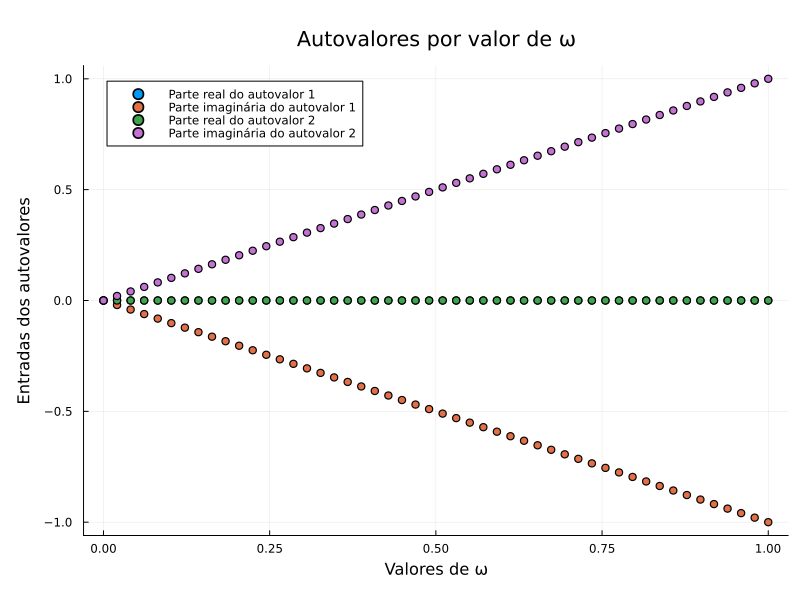

In [4]:
values = range(0, 1, length=50)
atvals1 = []
atvals2 = []
autovets = []

for ω in values
    A = [0 1; -ω^2 0]
    atval = eigvals(A)
    push!(atvals1, atval[1] + 0im)
    push!(atvals2, atval[2] + 0im)
    push!(autovets, eigvecs(A))
end

scatter(values, real.(atvals1), label="Parte real do autovalor 1", size=(800,600), title="\nAutovalores por valor de ω", top_margin=5Plots.mm)
scatter!(xlabel="Valores de ω", ylabel="Entradas dos autovalores", bottom_margin=5Plots.mm, left_margin=5Plots.mm)
scatter!(values, imag.(atvals1), label="Parte imaginária do autovalor 1")

scatter!(values, real.(atvals2), label="Parte real do autovalor 2")
scatter!(values, imag.(atvals2), label="Parte imaginária do autovalor 2")       

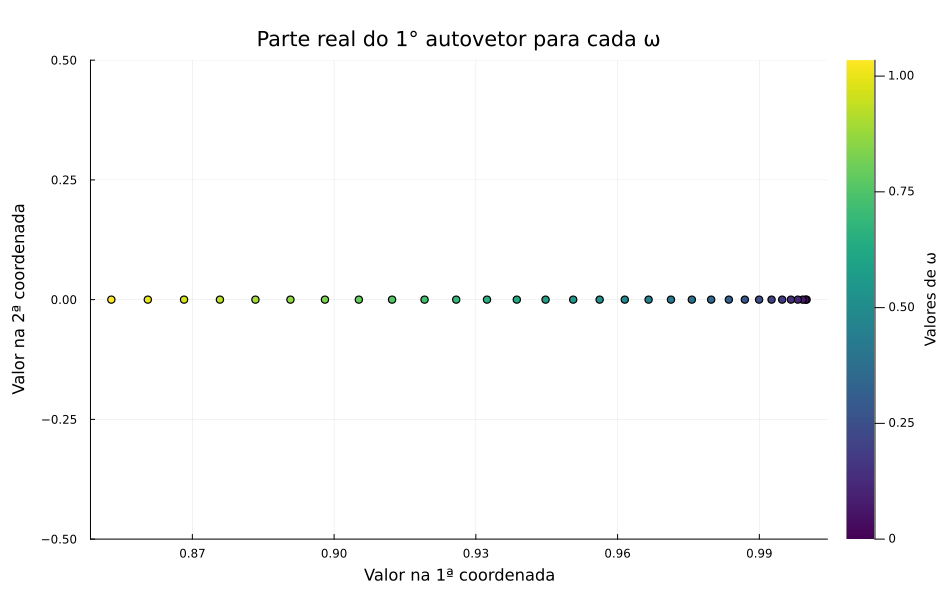

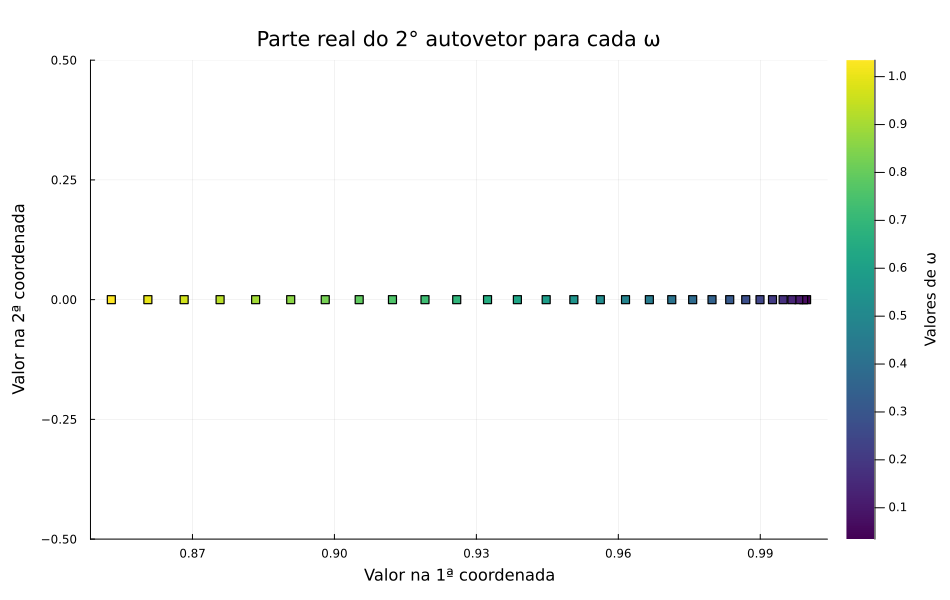

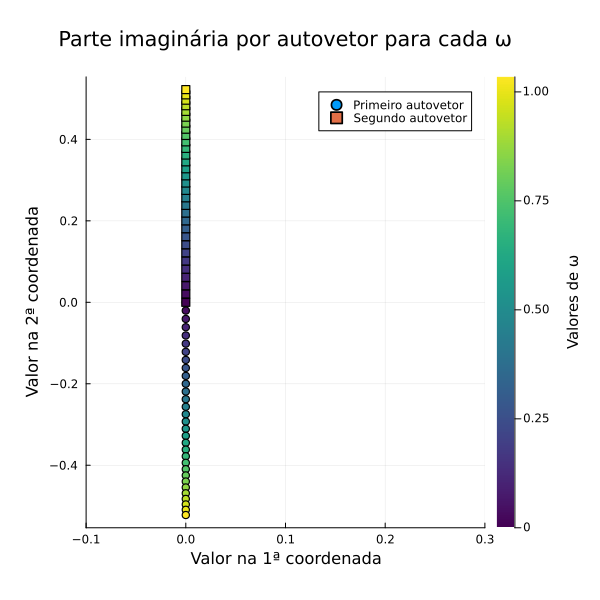

In [5]:
p1 = plot(title="\nParte real do 1° autovetor para cada ω", xlabel="Valor na 1ª coordenada", ylabel="Valor na 2ª coordenada", 
colorbar=true, colorbar_title = "Valores de ω", ylims=(-0.5, 0.5), size=(950,600), bottom_margin=5Plots.mm, 
left_margin=5Plots.mm, top_margin=5Plots.mm)

p2 = plot(title="\nParte real do 2° autovetor para cada ω", xlabel="Valor na 1ª coordenada", ylabel="Valor na 2ª coordenada", 
colorbar=true, colorbar_title = "Valores de ω", ylims=(-0.5, 0.5), size=(950,600), bottom_margin=5Plots.mm, 
left_margin=5Plots.mm, top_margin=5Plots.mm)

q = plot(title="\nParte imaginária por autovetor para cada ω", xlabel="Valor na 1ª coordenada",
ylabel="Valor na 2ª coordenada", xlims=(-0.1, 0.3), size=(600,600), colorbar=true, colorbar_title = "\nValores de ω")

scatter!(q, [NaN], [NaN], marker=:circle, label="Primeiro autovetor", bottom_margin=5Plots.mm, left_margin=5Plots.mm, top_margin=5Plots.mm)
scatter!(q, [NaN], [NaN], marker=:rect, label="Segundo autovetor", right_margin=8Plots.mm)

cmap1 = cgrad(:viridis)
cmap2 = cgrad(:inferno)

for i in 1:31
       t = (i - 1) / 29
       u1 = real.(autovets[i][:,1])
       w1 = imag.(autovets[i][:,1])

       scatter!(p1, [u1[1]], [u1[2]], zcolor=[t], colormap=:viridis, marker=:circle, label=false)
       scatter!(q, [w1[1]], [w1[2]], zcolor=[t], colormap=:viridis, marker=:circle, label=false)

       u2 = real.(autovets[i][:,2])
       w2 = imag.(autovets[i][:,2])

       if (i != 1)
              scatter!(p2, [u2[1]], [u2[2]], zcolor=[t], colormap=:viridis, marker=:rect, label=false)
       end
       scatter!(q, [w2[1]], [w2[2]], zcolor=[t], colormap=:viridis, marker=:rect, label=false)
end


display(p1)
display(p2)
display(q)

* Autovalores:

Quando $ω \to 0^{+}$, há uma diferença apenas na parte imaginária dos autovalores (já que a parte real é sempre 0 para ambos, configurando 2 autovalores imaginários puros), em que ambos tendem a 0, com o primeiro autovalor se aproximando de 0 pela esquerda e o segundo autovalor se aproximando de 0 pela direita como é mostrado no plot.

* Autovetores:

No caso dos autovetores, a diferença é mais complicada de interpretar, visto que ambos os autovetores tem coordenadas com valores imaginários pertencentes a $\mathbb{C}^2$. Nesse sentido, a abordagem escolhida, como demonstram os gráficos acima, foi dividir entre parte imaginária e real de cada autovetor. Os dois primeiros gráficos fazem a análise das partes reais das coordenadas de cada autovetor; no primeiro gráfico, percebe-se que na segunda coordenada a parte real é sempre 0, enquanto na primeira coordenada esse valor varia conforme $ω$ também varia, de modo que, quanto mais próximo de zero pela direita, mais a parte real da primeira coordenada se aproxima de 1; a análise é análoga para o segundo gráfico, apesar do segundo apresentar um ponto muito longe dos outros quando plotado com $ω$ exatamente igual a 0, já que, como a matriz A se torna $$\begin{bmatrix} 
0 & 1 \\ 
0 & 0 
\end{bmatrix}$$

a máquina tenta encontrar um segundo autovetor independente, modificando a segunda coordenada do segundo autovetor para um valor extremamente pequeno, tão pequeno que é interpretado como 0, e como x pode ser qualquer número, o valor escolhido é -1 (apesar de, matematicamente, essa matriz só possuir 1 autovetor), como mostra a figura abaixo:

<div align="center">
<img src="plot.png" width="700px" height="auto">
</div>

Já no último gráfico, o comportamento pércebido é de que, para a primeira coordenada, ambos os autovetores não possuem parte imaginária, já que é sempre igual a 0; em contrapartida, na segunda coordenada do primeiro autovetor, conforme $ω$ cresce, a parte imaginária tende a valores cada vez mais negativos, enquanto a do segundo autovetor tende a valores cada vez mais positivos. Em ambos os casos, conforme $ω$ tende a 0 pela direita, a parte imaginária da segunda coordenada tende a 0.

Portanto, conforme $ω \to 0^{+}$, ambos os autovalores tendem a 0 e os autovetores tendem a:

$$
v_1(\omega)\xrightarrow[\omega\to0^+]{}
\begin{bmatrix}
1\\
- i0
\end{bmatrix},
\qquad
v_2(\omega)\xrightarrow[\omega\to0^+]{}
\begin{bmatrix}
1\\
+ i0
\end{bmatrix}.
$$

Obs: para os plots foram escolhidos apenas os 30 primeiros valores de $ω$, já que é o suficiente para perceber a tendência, além de obter-se uma melhor visualização

#### Letra b)

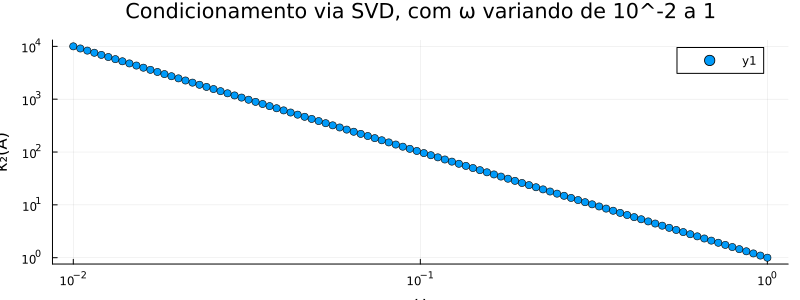

In [52]:
using LaTeXStrings
A(ω) = [0.0 1.0;
       -ω^2 0.0]

ωs = 10.0 .^ range(-2, 0, length=100)

conds = Float64[]
sval_max = Float64[]
sval_min = Float64[]

for ω in ωs
    F = svd(A(ω))

    omax = maximum(F.S)
    omin = minimum(F.S)

    push!(conds, omax/omin)
    push!(sval_max, omax)
    push!(sval_min, omin)
end

scatter(ωs, conds,
    xscale = :log10,
    yscale = :log10,
    xlabel = "ω",
    ylabel = "κ₂(A)",
    title = "Condicionamento via SVD, com ω variando de 10^-2 a 1", 
    size=(800,300), 
    top_margin=5Plots.mm)

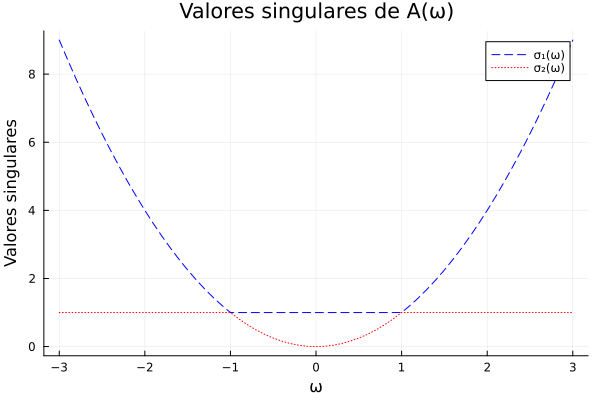

In [54]:
ωs = -3:0.1:3
svs = [svdvals(A(ω)) for ω in ωs]

σ1 = [s[1] for s in svs]
σ2 = [s[2] for s in svs]

plot(ωs, σ1, ls=:dash, label="σ₁(ω)", lw=1, color=:blue)
plot!(ωs, σ2, ls=:dot, label="σ₂(ω)", lw=1, color=:red)
xlabel!("ω")
ylabel!("Valores singulares")
title!("Valores singulares de A(ω)")

#### Dedução:
Note que o motivo das curvas parecerem se confundir no intervalo $|\omega| < 1$ é que os valores singulares de maneira que $\sigma_1 \le \sigma_2$, apenas. Ou seja, não representa algum comportamento anômalo, e isso pode ser comprovado no gráfico do condicionamento, onde aparece uma semirreta nesse intervalo.
Assim, podemos notar que, fora desse intervalo citado, $\sigma_1$ varia em forma de parábola, o que significa que $\sigma_1 \propto \omega ^2$, enquanto que $\sigma_2$ permanece constante, igual a 1.

Além disso, Repare que esse gráfico ($ω$, $\kappa_2 (A)$), plotado na escala de log10, passa pelos pontos (1, 1) e ($10^{-2}$, $10^4$). 

Dessa maneira, podemos deduzir que $\kappa_2 (A) = \frac{1}{\omega^2}$

#### Verificação analítica:
Sabemos que os valores singulares da decomposição SVD de $A(\omega)$ são as raízes quadradas dos autovalores de $A^T A$:
$$ A^T A = \begin{bmatrix} 0 & -\omega^2 \\ 1 & 0 \end{bmatrix} \begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix} = \begin{bmatrix} \omega^4 & 0 \\ 0 & 1 \end{bmatrix} $$
Logo $1$ e $|\omega|^2$ (=$\omega ^2$, para $\omega \in \mathbb R$). 

Desta forma, o número de condicionamento da matriz $A$ em relação à norma 2 é:
$$ \kappa(A) = \frac{\sigma_{max}}{\sigma_{min}} = \frac{1}{\omega^2} $$

, assumindo $0 < \omega \le 1$.

Com base no item anterior, conhecemos a matriz de autovetores: $S = \begin{bmatrix} 1 & 1 \\ i\omega & -i\omega \end{bmatrix}$.
Assim, calculando $S^* S$, temos que:
$$ S^* S = \begin{bmatrix} 1 & -i\omega \\ 1 & i\omega \end{bmatrix} \begin{bmatrix} 1 & 1 \\ i\omega & -i\omega \end{bmatrix} = \begin{bmatrix} 1+\omega^2 & 1-\omega^2 \\ 1-\omega^2 & 1+\omega^2 \end{bmatrix} $$
Os autovalores de $S^* S$ são: $2$ e $2\omega^2$. E, portanto, os valores singulares de $S$ são $\sqrt{2}$ e $\sqrt{2}\omega$. 

Logo, o condicionamento da matriz de autovetores de $A(\omega)$ em função de $\omega$ é:
$$ \kappa(S) = \frac{\sqrt{2}}{\sqrt{2}\omega} = \frac{1}{\omega} $$
**Isso explica analiticamente a instabilidade quando $\omega \to 0^+$, pois o condicionamento da base de autovetores diverge para o $+ \infty$.**

#### Letra c)

In [75]:
function exp1(ω, t)
    A = [0 1; -ω^2 0]
    if ω < 1e-15
        return I + t*A
    end
    return cos(ω*t)*I + sin(ω*t)/ω * A
end

function exp2(ω, t)
    A = [0 1; -ω^2 0]
    return exp(t * A)
end

exp2 (generic function with 1 method)

┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\pedro\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\pedro\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\pedro\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\pedro\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\pedro\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\pedro\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\pedro\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\pedro\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\pedro\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌

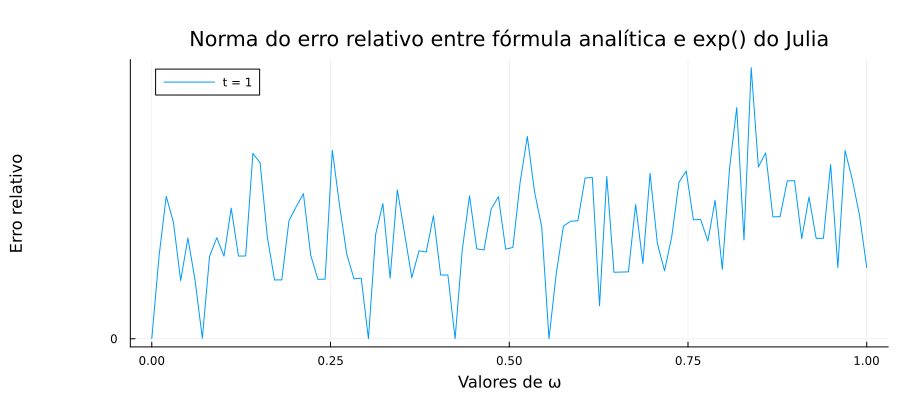

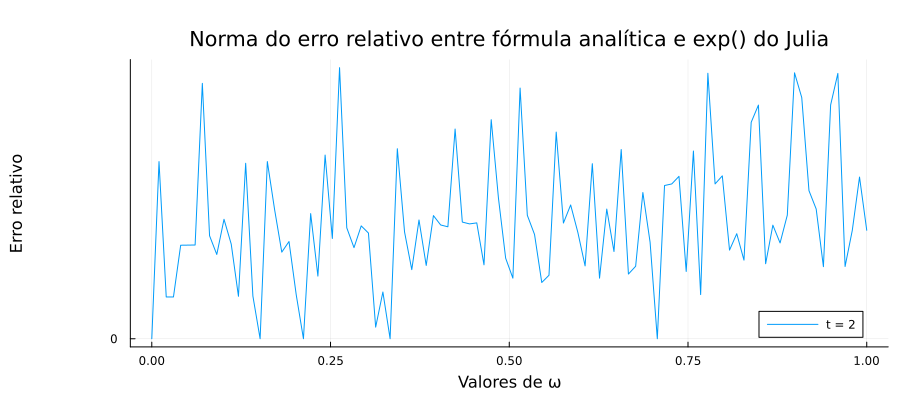

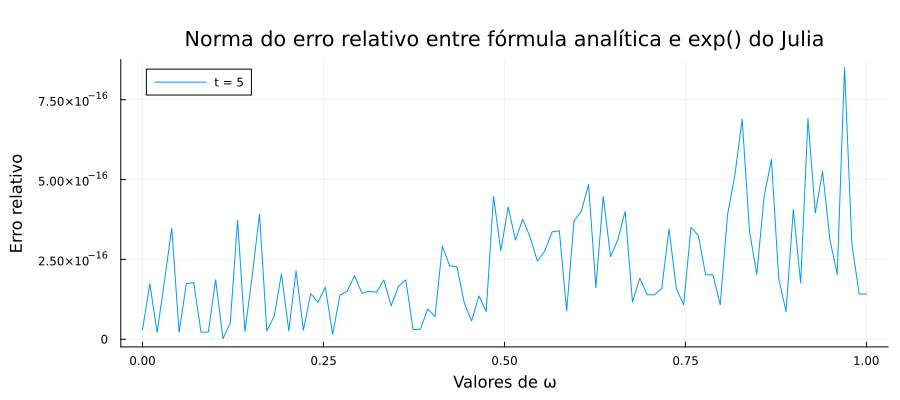

In [77]:
values = range(0, 1, length=100)
t = [1, 2, 5]
for value in t
    errors = []
    for ω in values
        push!(errors, norm(exp1(ω, value) - exp2(ω, value)) / norm(exp2(ω, value)))
    end

    p = plot(values, errors, xlabel="Valores de ω", ylabel="Erro relativo", title="\nNorma do erro relativo entre fórmula analítica e exp() do Julia", 
    label="t = $value", bottom_margin=5Plots.mm, left_margin=5Plots.mm, top_margin=7Plots.mm, size=(900,400))
    display(p)
end

A prova da primeira parte da letra c) segue na imagem abaixo:

<div align="center">
<img src="3c).jpeg" width="900px" height="auto">
</div>

Além disso, pelos gráficos acima, o erro relativo quando $ω \to 0^{+}$ é 0, ou seja, a fórmula de fato tende a $e^{tA(0)}$, já que, usando a exponencial de matriz direto (com o exp, na função exp2), $e^{tA(0)} = 1$ e como o erro relativo tende a 0, o limite da fórmula utilizando seno e cosseno tem de tender a 1 também, para zerar o erro relativo, ou seja, tendendo a $e^{tA(0)}$, como afirma a hipótese.